In [1]:
import pandas as pd
import matplotlib.pyplot as plt


                     Unnamed: 0  day_of_week  hour_of_day  is_weekend  \
timestamp                                                               
2023-01-01 00:00:00           0            6            0           1   
2023-01-01 01:00:00           1            6            1           1   
2023-01-01 02:00:00           2            6            2           1   
2023-01-01 03:00:00           3            6            3           1   
2023-01-01 04:00:00           4            6            4           1   

                     temperature  is_holiday  solar_generation   load  \
timestamp                                                               
2023-01-01 00:00:00    17.483571           0          7.819507  18493   
2023-01-01 01:00:00    14.308678           0          0.886376  17090   
2023-01-01 02:00:00    18.238443           0          0.798470  16052   
2023-01-01 03:00:00    22.615149           0          3.067700  15356   
2023-01-01 04:00:00    13.829233           0      

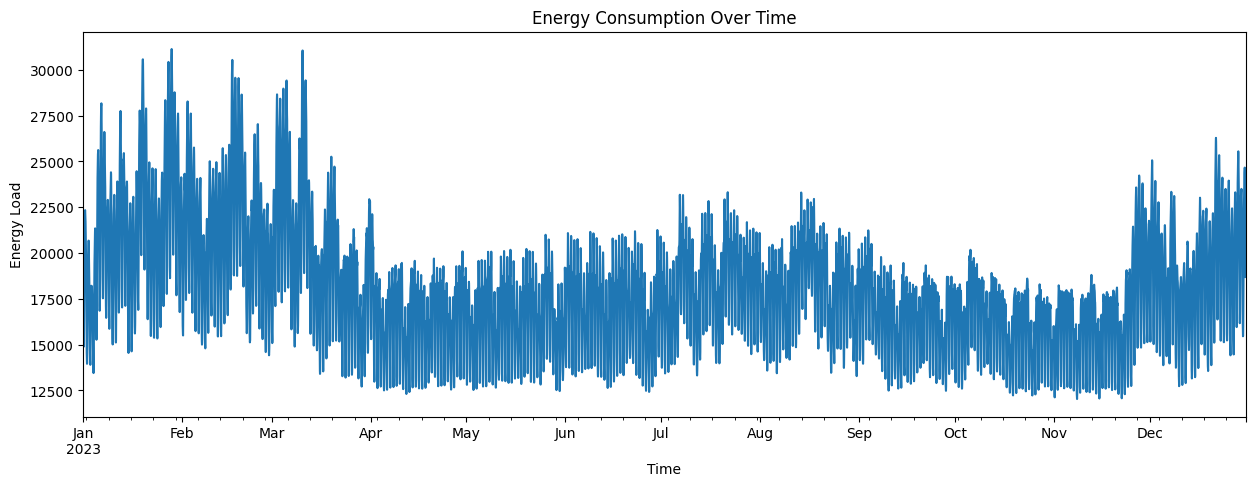

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv('/content/24-hours Delhi Power Consumption dataset.csv')

# Convert timestamp to datetime
data['timestamp'] = pd.to_datetime(data['timestamp'])

# Set as index
data.set_index('timestamp', inplace=True)

# Sort (important)
data.sort_index(inplace=True)

# Check data
print(data.head())

# Plot ENERGY (load)
data['load'].plot(figsize=(15,5), title="Energy Consumption Over Time")

plt.xlabel("Time")
plt.ylabel("Energy Load")
plt.show()

/tmp/ipykernel_11089/2948555107.py:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  numeric_data.fillna(method='ffill', inplace=True)


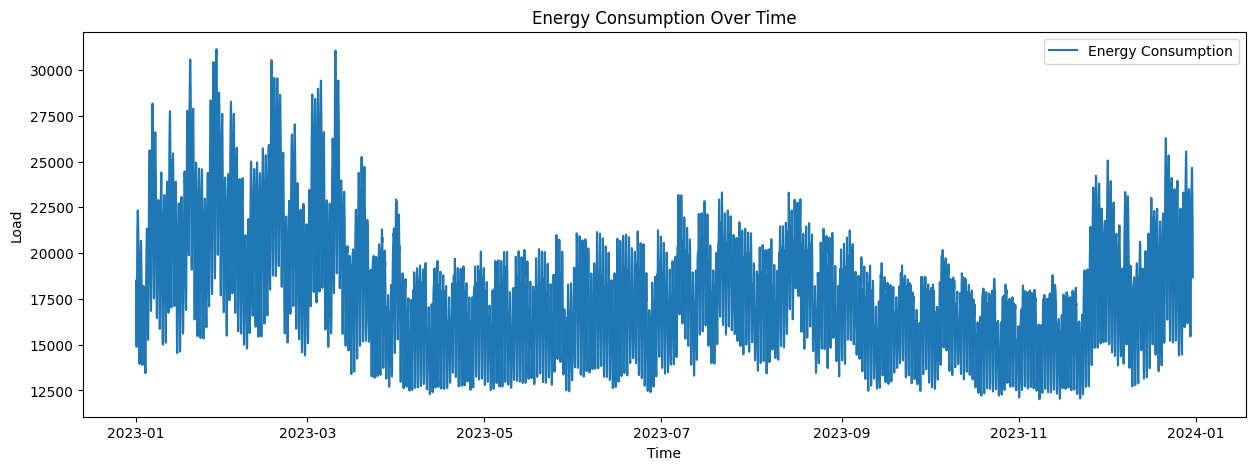

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv('/content/24-hours Delhi Power Consumption dataset.csv')

# Convert timestamp
data['timestamp'] = pd.to_datetime(data['timestamp'])
data.set_index('timestamp', inplace=True)

# Sort
data.sort_index(inplace=True)

# ✅ Keep only numeric columns
numeric_data = data.select_dtypes(include=['number'])

# ✅ Resample safely
numeric_data = numeric_data.resample('h').mean()

# Fill missing values
numeric_data.fillna(method='ffill', inplace=True)

# Plot
plt.figure(figsize=(15,5))
plt.plot(numeric_data['load'], label='Energy Consumption')

plt.title("Energy Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Load")
plt.legend()

plt.show()

In [10]:
# Assuming your dataframe already has datetime index

# Extract hour of day (0–23)
data['hour'] = data.index.hour

# Extract day of week (0=Monday, 6=Sunday)
data['day_of_week'] = data.index.dayofweek

# Optional: weekend flag (useful for ML)
data['is_weekend'] = data['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Preview
print(data[['hour', 'day_of_week', 'is_weekend']].head())

                     hour  day_of_week  is_weekend
timestamp                                         
2023-01-01 00:00:00     0            6           1
2023-01-01 01:00:00     1            6           1
2023-01-01 02:00:00     2            6           1
2023-01-01 03:00:00     3            6           1
2023-01-01 04:00:00     4            6           1


In [13]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# MSE
mse = mean_squared_error(y_test, predictions)

# RMSE
rmse = np.sqrt(mse)

# R2 Score
r2 = r2_score(y_test, predictions)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 8326771.201148479
RMSE: 2885.614527470445
R2 Score: 0.321165681375276


In [16]:
model.fit(X_train, y_train)
import joblib

# Save trained model
joblib.dump(model, 'energy_forecast_model.pkl')

print("Model saved successfully ✅")

Model saved successfully ✅


In [18]:
import os
print(os.listdir())

['.config', 'energy_forecast_model.pkl', 'household_power_consumption.txt.zip', 'archive.zip', '24-hours Delhi Power Consumption dataset.csv', 'sample_data']


In [20]:
import joblib
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
import pandas as pd

# Dummy small example (just to create model.pkl)
# (This avoids dependency on your previous errors)

# Create sample data
X = [[1,1],[2,2],[3,3],[4,4]]
y = [10,20,30,40]

# Train model
model = MLPRegressor(max_iter=1000)
model.fit(X, y)

# Save model
joblib.dump(model, 'model.pkl')

print("Model saved successfully ✅")

# Check files
import os
print("Files:", os.listdir())

Model saved successfully ✅
Files: ['.config', 'energy_forecast_model.pkl', 'household_power_consumption.txt.zip', 'archive.zip', 'model.pkl', '24-hours Delhi Power Consumption dataset.csv', 'sample_data']


In [21]:
from google.colab import files
files.download('model.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>